In [419]:
import pandas as pd

# Data Loading

In this section, the tourism arrivals dataset is loaded into Python using Pandas. 
This converts the CSV file into a DataFrame structure.

In [420]:
df=pd.read_csv("../Data/Raw/tourism_arrivals.csv")


In [421]:
print(df.head())

      date  arrivals
0  2014-01  146575.0
1  2014-02  141878.0
2  2014-03  133048.0
3  2014-04  112631.0
4  2014-05   90046.0


# Data Cleaning
Looking for if there any missing data. data types are correct

In [422]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      144 non-null    str    
 1   arrivals  136 non-null    float64
dtypes: float64(1), str(1)
memory usage: 2.4 KB
None


Convert date column into datetime format


In [423]:
df['date']=pd.to_datetime(df['date'])

In [424]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      144 non-null    datetime64[us]
 1   arrivals  136 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.4 KB
None


checking for missing values

remove null values

In [425]:
df=df.dropna()

In [426]:
print(df.isnull().sum())

date        0
arrivals    0
dtype: int64


In [427]:
import matplotlib.pyplot as plt

# Tourism Trend Visualization

A time-series plot is generated to visualize changes in tourist arrivals over time.

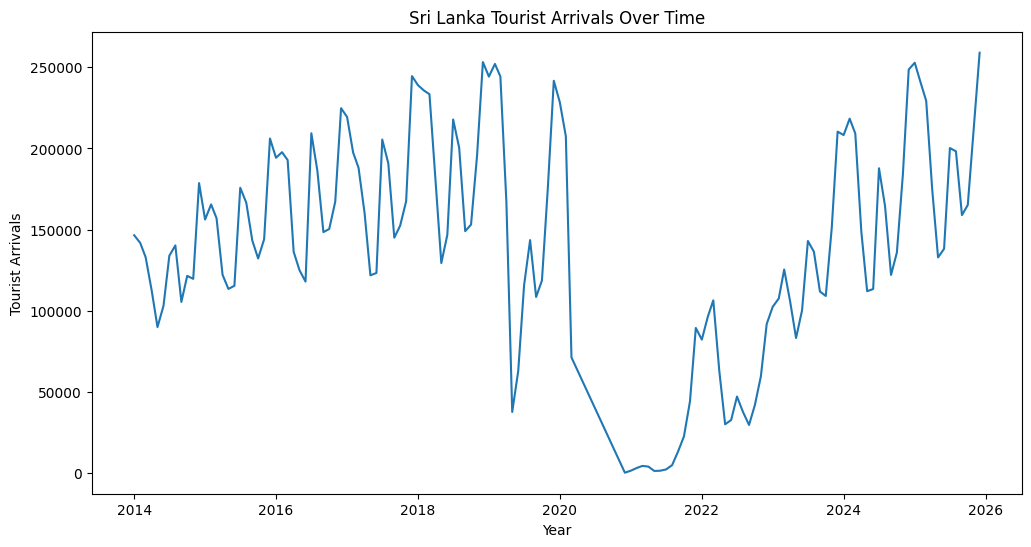

In [428]:
plt.figure(figsize=(12,6))
plt.plot(df['date'],df['arrivals'])

plt.title('Sri Lanka Tourist Arrivals Over Time')
plt.xlabel('Year')
plt.ylabel('Tourist Arrivals')

plt.show()

# Monthly Tourist Arrival Analysis

This analysis examines the average tourist arrivals according to month.We do that for identify seasonal tourism patterns in Sri Lanka.
Seasonality analysis is important because tourism demand changes throughout the year due to various factors.


In [429]:
df['month']=df['date'].dt.month_name()

In [430]:
monthly_average=df.groupby('month')['arrivals'].mean()

In [431]:
month_order=['January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']

monthly_average=monthly_average.reindex(month_order)

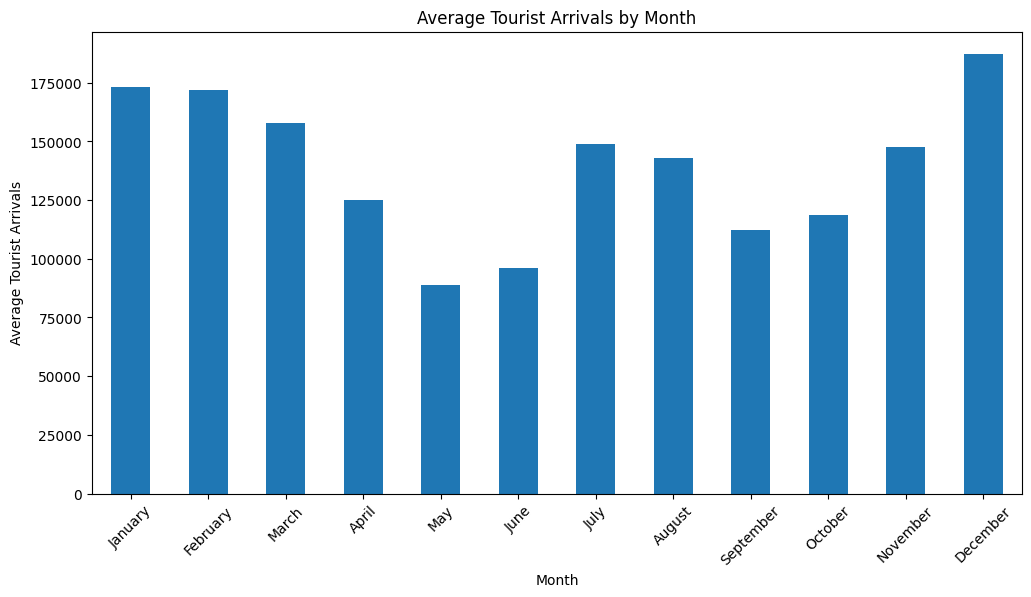

In [432]:
plt.figure(figsize=(12,6))
monthly_average.plot(kind='bar')

plt.title('Average Tourist Arrivals by Month')
plt.xlabel('Month')
plt.ylabel('Average Tourist Arrivals')
plt.xticks(rotation=45)

plt.show()

Save cleaned data set in "Cleaned" file

In [433]:
df.to_csv("../Data/Cleaned/tourism_arrivals_cleaned.scv")

# Interpretation of Monthly Tourism Patterns

The chart shows seasonal changes in tourist arrivals in Sri Lanka.

Some months have higher tourist arrivals, showing peak tourism seasons. This may be due to good weather, holidays, and travel trends.

Some months have lower arrivals, showing off-season periods or less international travel.

# COVID-19 Impact Analysis

This analysis evaluates the impact of the COVID-19 pandemic on Sri Lankan tourism arrivals.

The dataset is divided into three major periods:
- Pre-COVID period
- COVID-19 disruption period
- Post-COVID recovery period

This comparison shows how tourism changed and recovered over time.

In [434]:
df['year'] = df['date'].dt.year

In [435]:
#create period labels
df['period']='Pre-Covid'
df.loc[df['year'].between(2020,2021),'period']='Covid-period'
df.loc[df['year']>=2022,'period']='Recovery-Period'

In [436]:
print(df.head)

<bound method NDFrame.head of           date  arrivals      month  year           period
0   2014-01-01  146575.0    January  2014        Pre-Covid
1   2014-02-01  141878.0   February  2014        Pre-Covid
2   2014-03-01  133048.0      March  2014        Pre-Covid
3   2014-04-01  112631.0      April  2014        Pre-Covid
4   2014-05-01   90046.0        May  2014        Pre-Covid
..         ...       ...        ...   ...              ...
139 2025-08-01  198235.0     August  2025  Recovery-Period
140 2025-09-01  158971.0  September  2025  Recovery-Period
141 2025-10-01  165193.0    October  2025  Recovery-Period
142 2025-11-01  212906.0   November  2025  Recovery-Period
143 2025-12-01  258928.0   December  2025  Recovery-Period

[136 rows x 5 columns]>


In [437]:
#Calculate average arrivals by period
period_analysis=df.groupby('period')['arrivals'].mean()
print(period_analysis)

period
Covid-period        43887.437500
Pre-Covid          163059.305556
Recovery-Period    137984.729167
Name: arrivals, dtype: float64


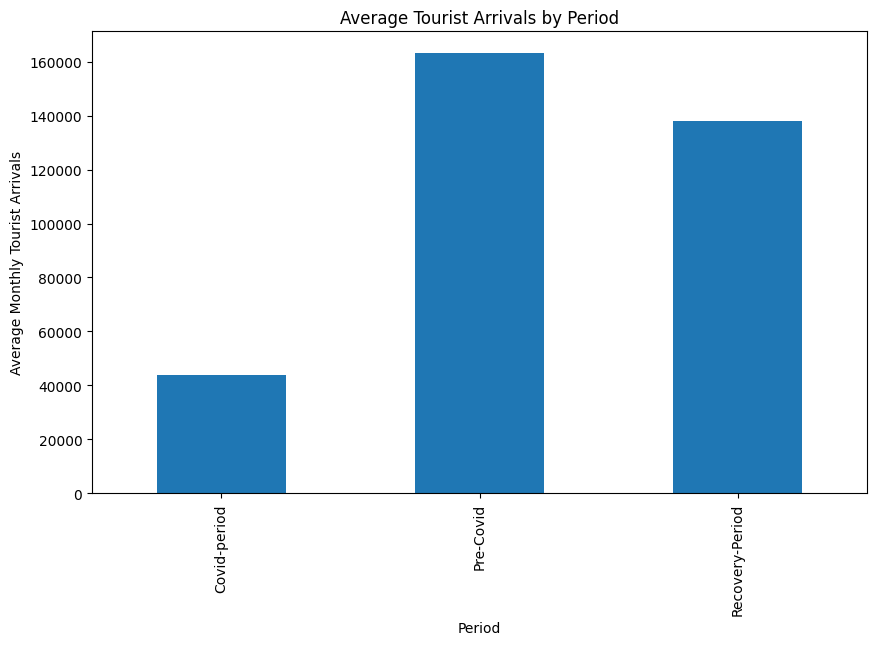

In [438]:
plt.figure(figsize=(10,6))
period_analysis.plot(kind='bar')
plt.title('Average Tourist Arrivals by Period')
plt.xlabel('Period')
plt.ylabel('Average Monthly Tourist Arrivals')

plt.show()

# Interpretation of COVID-19 Impact

Tourist arrivals dropped sharply during the COVID-19 period compared to the years before the pandemic.

Travel restrictions, lockdowns, and reduced international travel caused this decline in 2020 and 2021.

After COVID-19, tourist arrivals started to increase again. This shows the gradual recovery of tourism and international travel.

# Tourism Growth Rate Analysis

This analysis calculates the year-to-year percentage growth in tourist arrivals to evaluate tourism performance trends over time.

In [439]:
#Calculate yearly totals
yearly_arrivals=df.groupby('year')['arrivals'].sum()

In [440]:
#Calculate growth rate
growth_rate=yearly_arrivals.pct_change()*100

In [441]:
#Create a new table
growth_df=pd.DataFrame({
    'Yearly Arrivals':yearly_arrivals,
    'Growth Rate(%)':growth_rate
})
print(growth_df)


      Yearly Arrivals  Growth Rate(%)
year                                 
2014        1527153.0             NaN
2015        1798380.0       17.760303
2016        2050832.0       14.037745
2017        2116407.0        3.197483
2018        2333796.0       10.271607
2019        1913702.0      -18.000459
2020         507704.0      -73.470060
2021         194495.0      -61.691261
2022         719978.0      270.178154
2023        1487303.0      106.576173
2024        2053465.0       38.066352
2025        2362521.0       15.050463


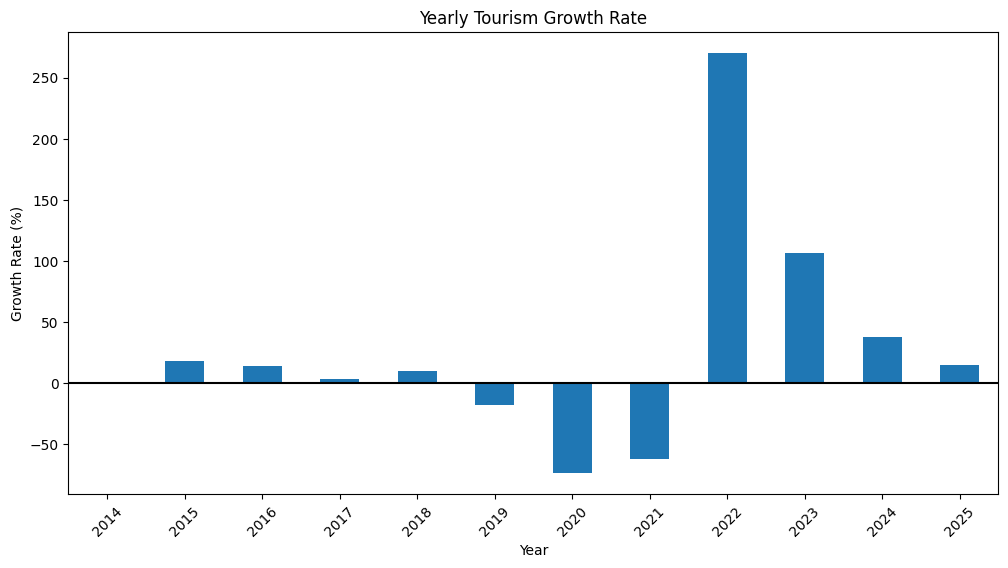

In [442]:
#Create growth rate chart
plt.figure(figsize=(12,6))
growth_df['Growth Rate(%)'].plot(kind='bar')
plt.title('Yearly Tourism Growth Rate')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.axhline(0,color='black')
plt.show()

# Interpretation of Growth Rate Trends

The growth rate shows big changes in Sri Lanka’s tourism over the years.

Positive growth means tourism increased. Negative growth means tourism decreased.

During COVID-19, there is a strong negative growth because travel was restricted worldwide.

After COVID-19, tourism starts to recover slowly as international travel reopens.

# Load Exchange Rate Dataset

The monthly USD/LKR exchange rate data is loaded for economic analysis.

This data will be combined with tourism arrivals data to study the relationship between exchange rate changes and tourism demand.

In [443]:
#Load exchange rate dataset
exchange_df=pd.read_csv("../Data/Raw/usd_lkr_exchange.csv")
print(exchange_df.head())

   Year     Month  USD_to_LKR_Avg
0  2014   January          130.71
1  2014  February          130.80
2  2014     March          130.63
3  2014     April          130.62
4  2014       May          130.43


In [444]:
#Check data stucture
print(exchange_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            144 non-null    int64  
 1   Month           144 non-null    str    
 2   USD_to_LKR_Avg  144 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.5 KB
None


The Year and Month columns are combined into one datetime column.
This helps organize the data for time-series analysis and merging datasets.


In [445]:
#Create date column by cobining year and month
exchange_df['date']=pd.to_datetime(
    exchange_df['Year'].astype(str)+'-'+exchange_df['Month'],format='%Y-%B'
)
print(exchange_df.head())

   Year     Month  USD_to_LKR_Avg       date
0  2014   January          130.71 2014-01-01
1  2014  February          130.80 2014-02-01
2  2014     March          130.63 2014-03-01
3  2014     April          130.62 2014-04-01
4  2014       May          130.43 2014-05-01


In [446]:
#keep only required columns
#Rename column for simplicity
exchange_df.rename(columns={'USD_to_LKR_Avg':'usd_lkr'},inplace=True)

exchange_df=exchange_df[['date','usd_lkr']]

print(exchange_df.head())

        date  usd_lkr
0 2014-01-01   130.71
1 2014-02-01   130.80
2 2014-03-01   130.63
3 2014-04-01   130.62
4 2014-05-01   130.43


# Merge Tourism and Exchange Rate Data

The tourism arrivals dataset and the exchange rate dataset are merged using a common date column.
This creates one combined dataset.
It helps to study the relationship between tourism and currency changes

In [447]:
#Merge datasets unsig date column
merged_df=pd.merge(df,exchange_df,on='date')
print(merged_df.head())

        date  arrivals     month  year     period  usd_lkr
0 2014-01-01  146575.0   January  2014  Pre-Covid   130.71
1 2014-02-01  141878.0  February  2014  Pre-Covid   130.80
2 2014-03-01  133048.0     March  2014  Pre-Covid   130.63
3 2014-04-01  112631.0     April  2014  Pre-Covid   130.62
4 2014-05-01   90046.0       May  2014  Pre-Covid   130.43


# Correlation Analysis

Correlation analysis is used to study the relationship between tourist arrivals and exchange rate changes.
It helps to see if currency value changes affect tourism demand.


In [448]:
correlation=merged_df[['arrivals','usd_lkr']].corr()
print(correlation)

          arrivals   usd_lkr
arrivals  1.000000 -0.156771
usd_lkr  -0.156771  1.000000


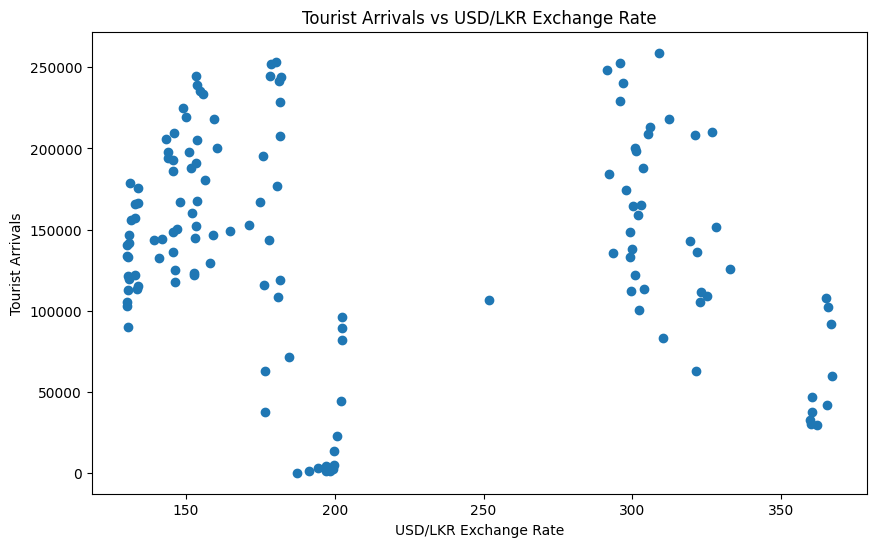

In [449]:
#Scatter plot of relationship between arrivals and usd_lkr
plt.figure(figsize=(10,6))
plt.scatter(merged_df['usd_lkr'],merged_df['arrivals'])
plt.title('Tourist Arrivals vs USD/LKR Exchange Rate')
plt.xlabel('USD/LKR Exchange Rate')
plt.ylabel('Tourist Arrivals')
plt.show()

# Interpretation of Exchange Rate Relationship

The correlation analysis shows a weak negative relationship between USD/LKR exchange rate and tourist arrivals.
The scatter plot does not show a clear linear pattern. The values are widely spread.
This means exchange rate changes alone do not strongly affect tourism demand in Sri Lanka.

# Time-Series Forecast Preparation

The dataset is prepared for forecasting by converting the date column into a time-series index.
It helps to identify trends, seasonality, and patterns in tourism arrivals over time.


In [450]:
#Create forcasting dataframe
forecast_df=df[['date','arrivals']].copy()

#set date as index
forecast_df.set_index('date',inplace=True)
print(forecast_df.head())
print(forecast_df.info())

            arrivals
date                
2014-01-01  146575.0
2014-02-01  141878.0
2014-03-01  133048.0
2014-04-01  112631.0
2014-05-01   90046.0
<class 'pandas.DataFrame'>
DatetimeIndex: 136 entries, 2014-01-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   arrivals  136 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB
None


# Tourism Time-Series Visualization

The cleaned tourism arrivals time series is plotted to study long-term trends.

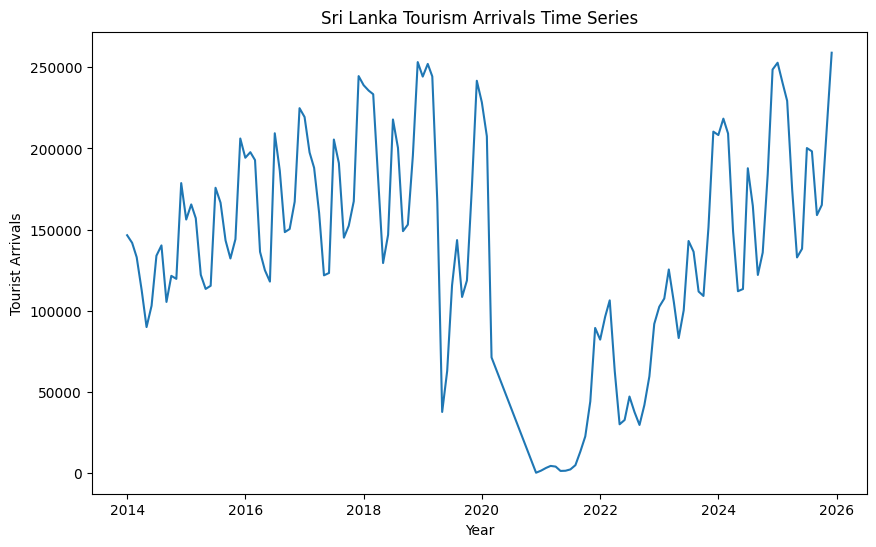

In [451]:
plt.figure(figsize=(10,6))
plt.plot(forecast_df.index,forecast_df['arrivals'])
plt.title('Sri Lanka Tourism Arrivals Time Series')
plt.xlabel('Year')
plt.ylabel('Tourist Arrivals')

plt.show()

# Train-Test Split

The dataset is divided into training and testing data.
The training data is used to build the forecasting model.
The testing data is used to check how well the model predicts future values.

In [452]:
#Split dataset
train=forecast_df[:'2023']
test=forecast_df['2024':]

#Display Shapes
print("Training Data:",train.shape)
print("Testing Data:",test.shape)

Training Data: (112, 1)
Testing Data: (24, 1)


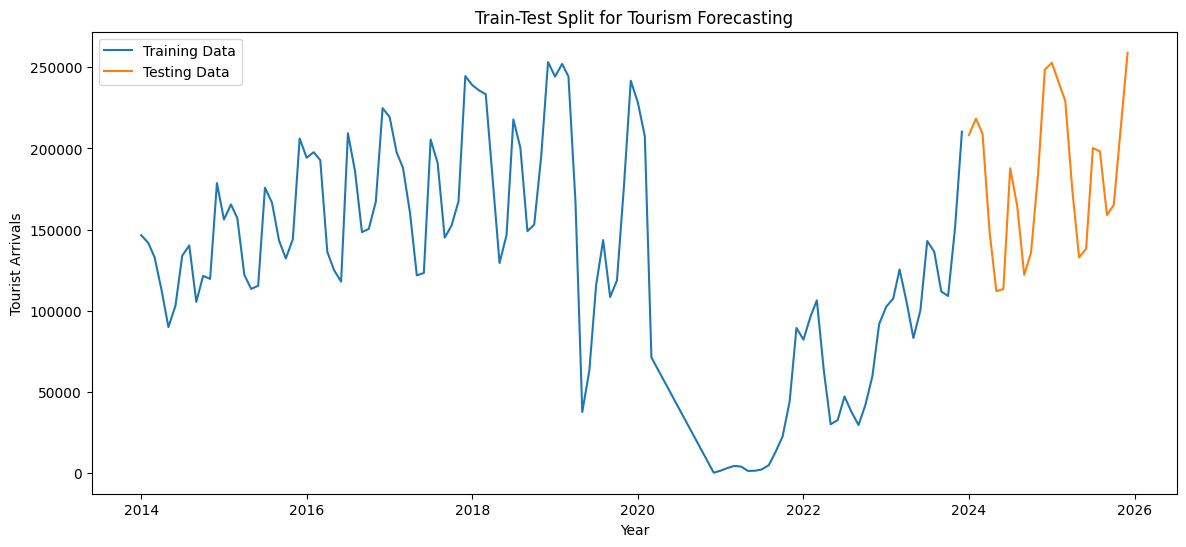

In [453]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train['arrivals'], label='Training Data')
plt.plot(test.index, test['arrivals'], label='Testing Data')

plt.title('Train-Test Split for Tourism Forecasting')
plt.xlabel('Year')
plt.ylabel('Tourist Arrivals')

plt.legend()

plt.show()

# Import Prophet Forecasting Model

The Prophet forecasting model is imported to perform tourism arrival forecasting.

Prophet is a time-series forecasting tool designed to automatically capture trends, seasonality, and temporal patterns in historical data.

In [454]:
!pip install prophet
#import prophet
from prophet import Prophet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Prepare Dataset for Prophet Forecasting

The forecasting dataset is reformatted according to Prophet model requirements.

Prophet requires:
- ds → datetime column
- y → target variable column

In [455]:
prophet_df=forecast_df.reset_index()
prophet_df.columns=['ds','y']
print(prophet_df.head())

          ds         y
0 2014-01-01  146575.0
1 2014-02-01  141878.0
2 2014-03-01  133048.0
3 2014-04-01  112631.0
4 2014-05-01   90046.0


In [456]:
from prophet import Prophet

# Train-Test Split for Prophet

The dataset is divided into training and testing periods.
Training data is used to learn historical tourism patterns, while testing data is reserved to evaluate forecasting accuracy on unseen future observations.

In [457]:
train_prophet=prophet_df[prophet_df['ds']<'2024-01-01']
test_prophet=prophet_df[prophet_df['ds']>='2024-01-01']
print('Train Data : ', train_prophet.shape)
print('Test Data : ' , test_prophet.shape)

Train Data :  (112, 2)
Test Data :  (24, 2)


# Create Prophet Forecasting Model

In [458]:
#Initialize prophet model
model=Prophet()

# Train the Forecasting Model

The Prophet model is trained using historical tourism arrivals data from the training dataset.

In [459]:
#Train model using training data
model.fit(train_prophet)

10:57:25 - cmdstanpy - INFO - Chain [1] start processing
10:57:26 - cmdstanpy - INFO - Chain [1] done processing


# Create Future Time Periods

Future monthly dates are generated for forecasting.

In [460]:
future=model.make_future_dataframe(
    periods=24,
    freq='MS'
)


print(future.tail())

            ds
131 2025-08-01
132 2025-09-01
133 2025-10-01
134 2025-11-01
135 2025-12-01


# Generate Tourism Forecasts

The trained Prophet model is used to predict future tourism arrivals for the testing period (2024–2025).

In [461]:
#Generate Forecasts
forecast=model.predict(future)

#View important forecast columns
forecast[['ds','yhat','yhat_lower','yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2014-01-01,189405.498540,130970.019485,252085.834505
1,2014-02-01,188948.797241,118801.441851,252877.569646
2,2014-03-01,174384.448485,108303.615678,235817.491805
3,2014-04-01,144764.092702,77010.801673,211398.328545
4,2014-05-01,109721.152182,44649.008878,180049.356430
...,...,...,...,...
131,2025-08-01,61693.886351,-936.054565,129240.033049
132,2025-09-01,33711.342050,-33953.645517,99282.438784
133,2025-10-01,38577.601153,-30272.855299,103879.089416
134,2025-11-01,62751.256915,-3316.880073,127322.048706


# Forecast plot

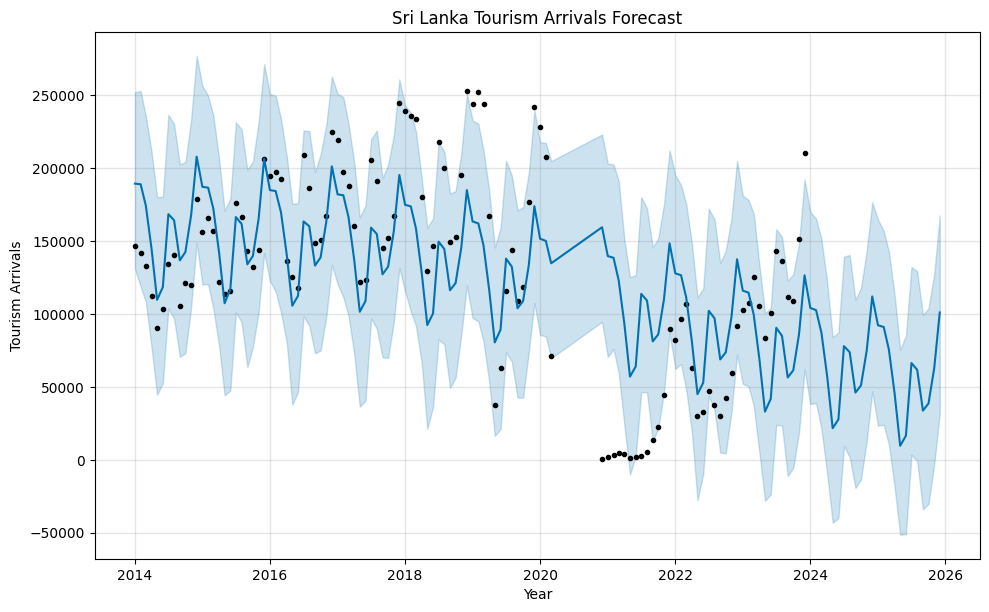

In [462]:
fig=model.plot(forecast)
plt.title("Sri Lanka Tourism Arrivals Forecast")
plt.xlabel("Year")
plt.ylabel("Tourism Arrivals")

plt.show()

# Interpretation of Forecast Results

The forecast shows clear seasonal patterns in tourist arrivals. Peaks and drops repeat every year.
The shaded area shows uncertainty in the forecast. It means future values can vary within this range.
The model captures past seasonality well.
However, the future trend is more cautious. This may be due to COVID-19 data affecting the model.
More testing is needed to check how accurate the predictions are compared to real data.

# Forecast Accuracy Evaluation

Forecast accuracy is measured to evaluate the Prophet model’s performance.
The predicted tourism arrivals for 2024–2025 are compared with actual values.
Two main metrics are used:
Mean Absolute Error (MAE)
Root Mean Square Error (RMSE)
Lower values mean better accuracy and closer predictions to real tourism arrivals.

In [463]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

forecast_test = forecast[forecast['ds'] >= '2024-01-01']

actual = test_prophet['y'].values
predicted = forecast_test['yhat'].values

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

MAE: 120215.32
RMSE: 122658.75


# Actual vs Predicted Tourism Arrivals

The actual tourism arrivals are compared with the forecasted values generated by the Prophet model.

This comparison helps visualize forecasting accuracy and identify periods where the model overestimates or underestimates tourism demand.

In [464]:
#Create comparison data frama
comparison=pd.DataFrame({
    'Date':test_prophet['ds'].values,
    'Actual':actual,
    'Predicted':predicted
})
comparison.head()

,Date,Actual,Predicted
0,2024-01-01,208253.0,104119.401292
1,2024-02-01,218350.0,102649.913147
2,2024-03-01,209181.0,87290.630099
3,2024-04-01,148867.0,57478.510983
4,2024-05-01,112128.0,21624.912640


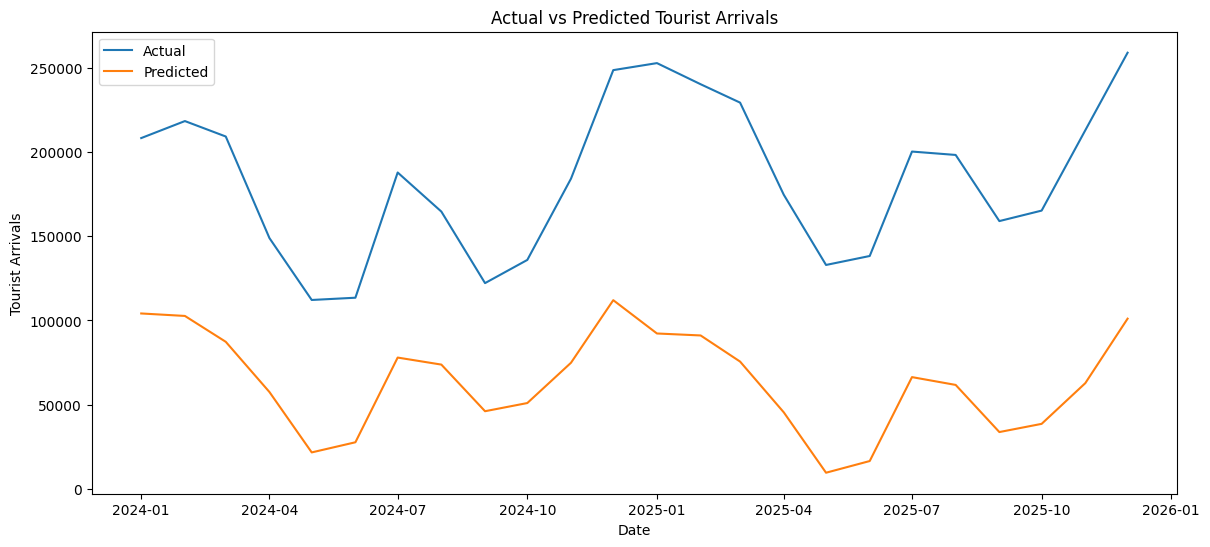

In [465]:
plt.figure(figsize=(14,6))
plt.plot(
    comparison['Date'],
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Date'],
    comparison['Predicted'],
    label='Predicted'
)

plt.title('Actual vs Predicted Tourist Arrivals')
plt.xlabel('Date')
plt.ylabel('Tourist Arrivals')

plt.legend()

plt.show()

# Interpretation of Forecast Results
The Prophet model successfully captured the seasonal pattern of tourist arrivals. Both the actual and predicted values show similar ups and downs over time.
However, the model generally underestimated tourist arrivals during 2024–2025. The actual arrivals were higher than the predicted values in most months.
This is shown by the relatively high error values:
MAE: 120,215 touristsRMSE: 122,659 tourists
One reason for this may be the inclusion of the COVID-19 period in the training data. The very low tourist arrivals during 2020–2021 affected the model's understanding of long-term trends and resulted in more conservative forecasts.
Although the model captured seasonality well, it did not fully reflect the strong recovery of Sri Lanka's tourism sector after international travel resumed.
Overall, the Prophet model is effective for identifying seasonal patterns, but further improvements may be needed to better forecast periods affected by major events such as the COVID-19 pandemic.

# Create Training Dataset Without COVID Period

A second forecasting model is created by removing the COVID-19 period (2020–2021) from the training data.

This is done to examine whether the sharp decline in tourist arrivals during the pandemic affected the model's forecasting accuracy.

The results can be compared with the first model to determine if excluding the COVID-19 period improves forecast performance.

In [466]:
#Remove covid years from training dataset
train_prophet_no_covid=train_prophet[~train_prophet['ds'].dt.year.isin([2020,2021])]

print("Original Training Records:", len(train_prophet))
print("Training Records Without COVID:", len(train_prophet_no_covid))

Original Training Records: 112
Training Records Without COVID: 96


# Forecasting Model Without COVID Period

A second Prophet forecasting model is built after removing the COVID-19 period (2020–2021) from the training data.
The aim is to check whether the pandemic drop affected forecasting results.
This helps to see if extreme COVID-19 changes reduced model accuracy or distorted trend estimation.
The results will be compared with the original model that used the full dataset.

In [467]:
#Create second prophet model
model2=Prophet()

#Train model using data without COVID period
model2.fit(train_prophet_no_covid)

10:57:27 - cmdstanpy - INFO - Chain [1] start processing
10:57:27 - cmdstanpy - INFO - Chain [1] done processing


In [468]:
#Generate forecasts
forecast2=model2.predict(future)
forecast2[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
131,2025-08-01,73610.191018,31987.053661,115237.435091
132,2025-09-01,37281.339352,-4320.836210,81267.285750
133,2025-10-01,45442.720822,1240.841601,85832.203677
134,2025-11-01,64115.081648,23765.294008,104163.822489
135,2025-12-01,123737.681873,83631.896268,166573.679924


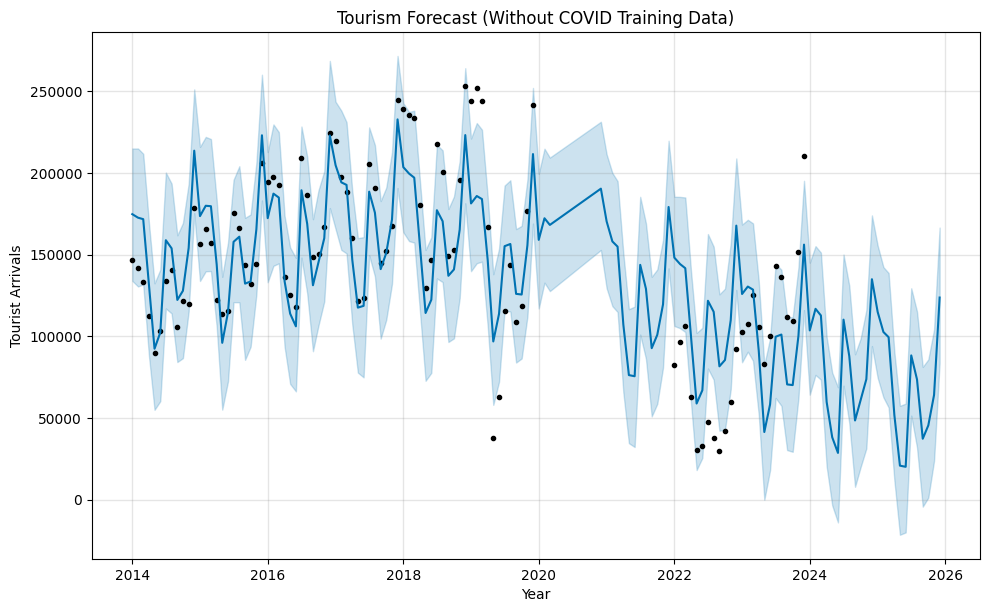

In [469]:
fig = model2.plot(forecast2)

plt.title('Tourism Forecast (Without COVID Training Data)')
plt.xlabel('Year')
plt.ylabel('Tourist Arrivals')

plt.show()

In [470]:
forecast2_test = forecast2[
    forecast2['ds'] >= '2024-01-01'
]

predicted2 = forecast2_test['yhat'].values

mae2 = mean_absolute_error(
    actual,
    predicted2
)

rmse2 = np.sqrt(
    mean_squared_error(
        actual,
        predicted2
    )
)

print("Model 2 MAE:", round(mae2,2))
print("Model 2 RMSE:", round(rmse2,2))

Model 2 MAE: 108251.88
Model 2 RMSE: 110544.54


# Comparison of Forecasting Models

Two Prophet forecasting models were developed and tested.
Model 1 used the full dataset, including the COVID-19 period. Model 2 removed the COVID-19 years (2020–2021).
Model 2 performed better, with lower MAE and RMSE values. This shows it was more accurate.
The COVID-19 period created a sudden drop in tourism, which affected long-term trend learning in Model 1.
This means unusual events can reduce forecast accuracy and should be handled carefully in modeling.


# Inflation Data Analysis

Monthly inflation data is added to the tourism analysis.
This helps examine whether inflation affects tourism demand in Sri Lanka.
Inflation can influence travel costs, living expenses, and consumer spending.
These factors may affect the number of international tourists visiting the country.

In [471]:
#Load inflation data
inflation_df=pd.read_csv('../Data/Raw/inflation_data.csv')

print(inflation_df.head())

   Year     Month     Date  Inflation_Rate_YoY_Percent       Notes
0  2014   January  2014-01                         4.2  CCPI based
1  2014  February  2014-02                         3.9  CCPI based
2  2014     March  2014-03                         4.0  CCPI based
3  2014     April  2014-04                         3.5  CCPI based
4  2014       May  2014-05                         3.2  CCPI based


In [472]:
print(inflation_df.info())
print(inflation_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        149 non-null    int64  
 1   Month                       149 non-null    str    
 2   Date                        149 non-null    str    
 3   Inflation_Rate_YoY_Percent  149 non-null    float64
 4   Notes                       149 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 5.9 KB
None
Year                          0
Month                         0
Date                          0
Inflation_Rate_YoY_Percent    0
Notes                         0
dtype: int64


In [473]:
# Convert date column

inflation_df['date'] = pd.to_datetime(
    inflation_df['Date']
)

print(
    inflation_df[
        ['date','Inflation_Rate_YoY_Percent']
    ].head()
)

        date  Inflation_Rate_YoY_Percent
0 2014-01-01                         4.2
1 2014-02-01                         3.9
2 2014-03-01                         4.0
3 2014-04-01                         3.5
4 2014-05-01                         3.2


In [474]:
#Keep only requared columns
inflation_df=inflation_df[['date','Inflation_Rate_YoY_Percent']]
inflation_df.rename(columns={
    'Inflation_Rate_YoY_Percent':'inflation'
},
inplace=True)
print(inflation_df.head())


        date  inflation
0 2014-01-01        4.2
1 2014-02-01        3.9
2 2014-03-01        4.0
3 2014-04-01        3.5
4 2014-05-01        3.2


In [475]:
print('Start Date : ',inflation_df['date'].min())
print('End Date : ',inflation_df['date'].max())
print(len(inflation_df['date']))

Start Date :  2014-01-01 00:00:00
End Date :  2026-05-01 00:00:00
149


# Merge Tourism and Inflation Data

The tourism arrivals dataset and inflation dataset are merged using a common date column.
This creates a single dataset containing both tourism and inflation information.
It allows the relationship between inflation and tourism demand in Sri Lanka to be analyzed.


In [476]:
tourism_inflation_df=pd.merge(
    df,
    inflation_df,
    on='date'
)
print(tourism_inflation_df.head())
print(len(tourism_inflation_df))

        date  arrivals     month  year     period  inflation
0 2014-01-01  146575.0   January  2014  Pre-Covid        4.2
1 2014-02-01  141878.0  February  2014  Pre-Covid        3.9
2 2014-03-01  133048.0     March  2014  Pre-Covid        4.0
3 2014-04-01  112631.0     April  2014  Pre-Covid        3.5
4 2014-05-01   90046.0       May  2014  Pre-Covid        3.2
136


# Correlation Analysis

Correlation analysis is performed to study the relationship between tourism arrivals and inflation.
The correlation coefficient shows how strongly the two variables are related.
It also indicates whether the relationship is positive or negative.


In [477]:
correlation=tourism_inflation_df[['arrivals','inflation']].corr()
print(correlation)

           arrivals  inflation
arrivals    1.00000   -0.40852
inflation  -0.40852    1.00000


# Scatter Plot

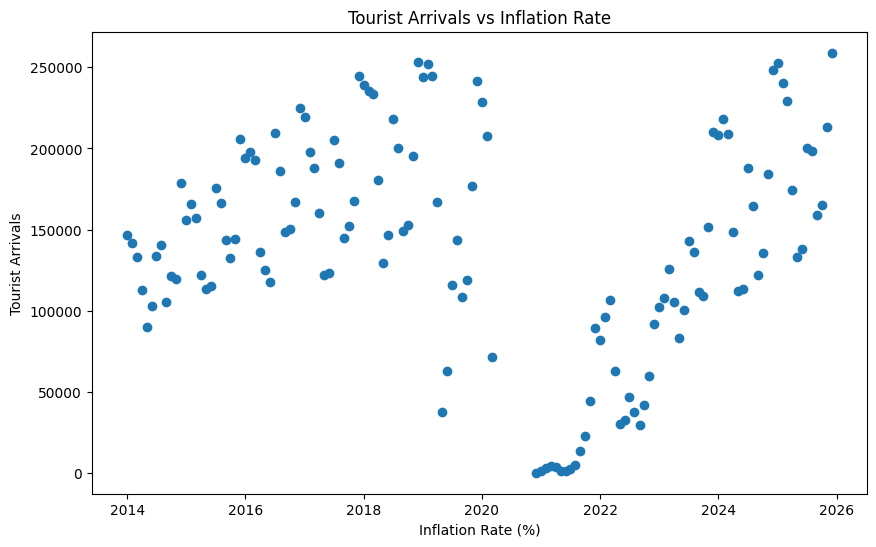

In [478]:
plt.figure(figsize=(10,6))

plt.scatter(
    tourism_inflation_df['date'],
    tourism_inflation_df['arrivals']
)
plt.title(
    'Tourist Arrivals vs Inflation Rate'
)

plt.xlabel('Inflation Rate (%)')

plt.ylabel('Tourist Arrivals')

plt.show()

# Inflation Trend Over Time

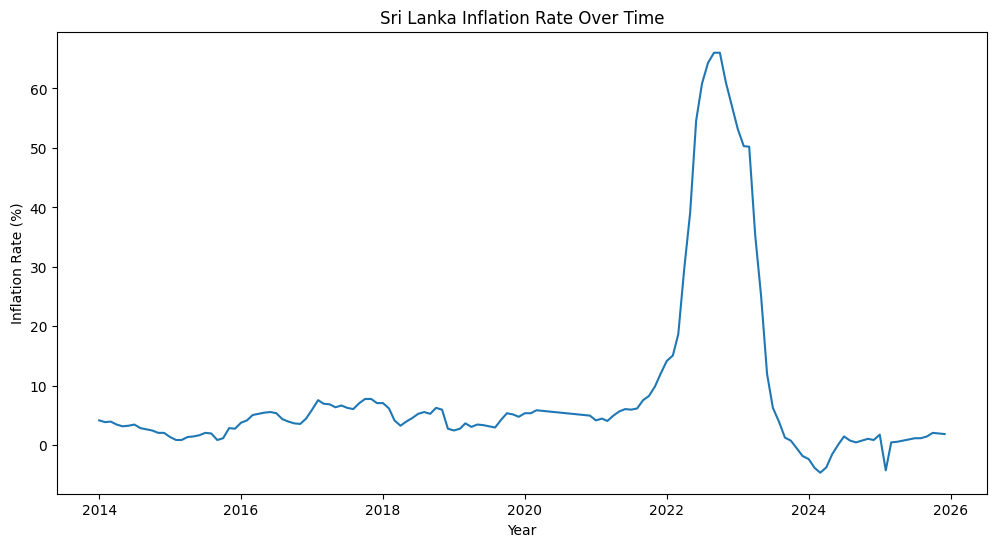

In [479]:
plt.figure(figsize=(12,6))

plt.plot(
    tourism_inflation_df['date'],
    tourism_inflation_df['inflation']
)

plt.title('Sri Lanka Inflation Rate Over Time')

plt.xlabel('Year')

plt.ylabel('Inflation Rate (%)')

plt.show()

# Interpretation of Inflation Analysis

The correlation analysis revealed a moderate negative relationship between inflation and tourist arrivals (r = -0.409).

Compared with the exchange rate analysis, inflation exhibited a stronger association with tourism demand, suggesting that broader economic conditions may have a greater influence on tourism performance.

The inflation trend shows a significant spike during the 2022 economic crisis, reaching historically high levels. This period coincided with reduced tourism activity and economic instability.

The scatter plot indicates that higher inflation periods are generally associated with lower tourist arrivals, although the relationship is not perfectly linear. Other factors such as the COVID-19 pandemic, political conditions, and global travel trends may also influence tourism demand.

Overall, inflation appears to be a more informative explanatory variable than the exchange rate and may be useful for future forecasting models.

# Peace Index Data Analysis

In [480]:
peace_df=pd.read_csv("../Data/Raw/global_peace_index_data.csv")

peace_df[peace_df['Country'].str.contains(
    'Sri',
        case=False,
        na=False
)]

,Country,Region,GPI_2014_Score,GPI_2014_Rank,GPI_2015_Score,GPI_2015_Rank,GPI_2016_Score,GPI_2016_Rank,GPI_2017_Score,GPI_2017_Rank,...,GPI_2021_Score,GPI_2021_Rank,GPI_2022_Score,GPI_2022_Rank,GPI_2023_Score,GPI_2023_Rank,GPI_2024_Score,GPI_2024_Rank,GPI_2025_Score,GPI_2025_Rank
80,Sri Lanka,South Asia,1.974,81,1.973,72,2.058,81,1.98,73,...,1.994,72,1.978,70,1.938,67,1.938,67,1.943,70


In [481]:
sri_lanka = peace_df[
    peace_df['Country'].str.contains(
        'Sri',
        case=False,
        na=False
    )
]

print(sri_lanka.T)

                        80
Country          Sri Lanka
Region          South Asia
GPI_2014_Score       1.974
GPI_2014_Rank           81
GPI_2015_Score       1.973
GPI_2015_Rank           72
GPI_2016_Score       2.058
GPI_2016_Rank           81
GPI_2017_Score        1.98
GPI_2017_Rank           73
GPI_2018_Score        1.98
GPI_2018_Rank           71
GPI_2019_Score       2.011
GPI_2019_Rank           72
GPI_2020_Score       2.011
GPI_2020_Rank           71
GPI_2021_Score       1.994
GPI_2021_Rank           72
GPI_2022_Score       1.978
GPI_2022_Rank           70
GPI_2023_Score       1.938
GPI_2023_Rank           67
GPI_2024_Score       1.938
GPI_2024_Rank           67
GPI_2025_Score       1.943
GPI_2025_Rank           70


In [482]:
peace_data = {
    'year': [
        2014,2015,2016,2017,2018,2019,
        2020,2021,2022,2023,2024,2025
    ],

    'peace_index': [
        1.974,
        1.973,
        2.058,
        1.980,
        1.980,
        2.011,
        2.011,
        1.994,
        1.978,
        1.938,
        1.938,
        1.943
    ]
}

peace_df = pd.DataFrame(peace_data)

print(peace_df)

    year  peace_index
0   2014        1.974
1   2015        1.973
2   2016        2.058
3   2017        1.980
4   2018        1.980
5   2019        2.011
6   2020        2.011
7   2021        1.994
8   2022        1.978
9   2023        1.938
10  2024        1.938
11  2025        1.943


In [483]:
#Create Year Column in Tourism Dataset
df['year'] = df['date'].dt.year

print(df[['date','year']].head())

        date  year
0 2014-01-01  2014
1 2014-02-01  2014
2 2014-03-01  2014
3 2014-04-01  2014
4 2014-05-01  2014


# Peace Index Analysis

The Global Peace Index is incorporated to examine whether political stability and national security conditions influence tourism demand in Sri Lanka.

Countries perceived as safer destinations often attract higher levels of international tourism.

In [484]:
tourism_peace_df = pd.merge(
    df,
    peace_df,
    on='year'
)

print(tourism_peace_df.head())

        date  arrivals     month  year     period  peace_index
0 2014-01-01  146575.0   January  2014  Pre-Covid        1.974
1 2014-02-01  141878.0  February  2014  Pre-Covid        1.974
2 2014-03-01  133048.0     March  2014  Pre-Covid        1.974
3 2014-04-01  112631.0     April  2014  Pre-Covid        1.974
4 2014-05-01   90046.0       May  2014  Pre-Covid        1.974


# Correlation Analysis

In [485]:
peace_corr = tourism_peace_df[
    ['arrivals','peace_index']
].corr()

print(peace_corr)

             arrivals  peace_index
arrivals     1.000000    -0.056044
peace_index -0.056044     1.000000


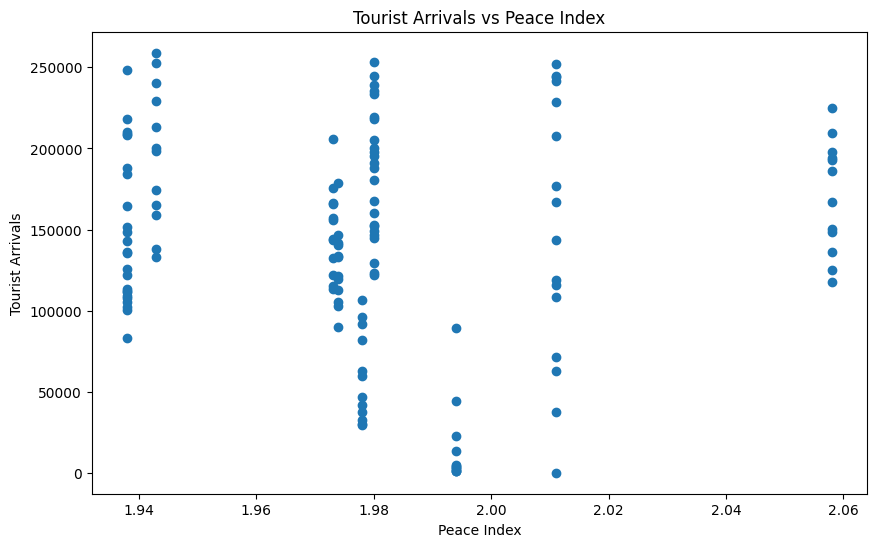

In [486]:
plt.figure(figsize=(10,6))

plt.scatter(
    tourism_peace_df['peace_index'],
    tourism_peace_df['arrivals']
)

plt.title(
    'Tourist Arrivals vs Peace Index'
)

plt.xlabel('Peace Index')

plt.ylabel('Tourist Arrivals')

plt.show()

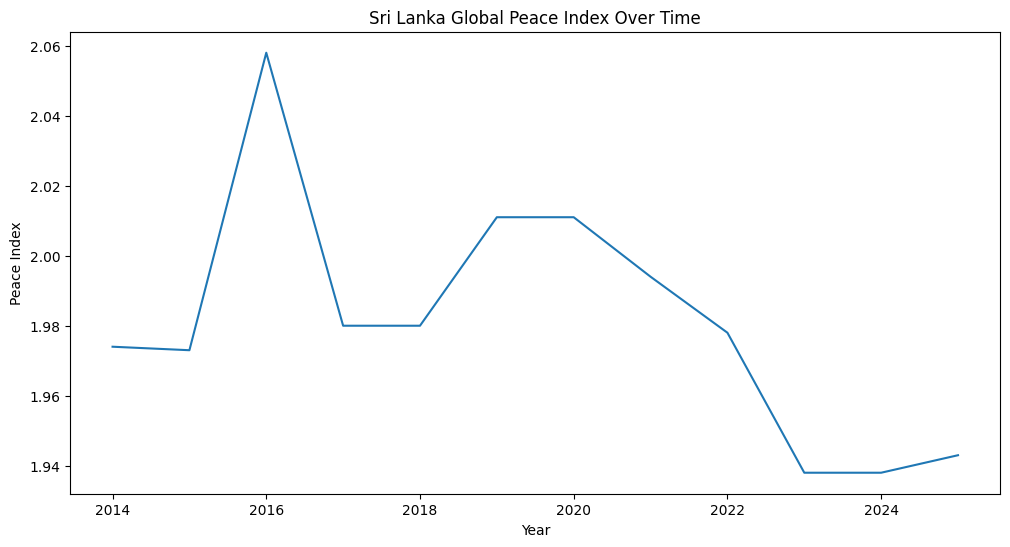

In [487]:
plt.figure(figsize=(12,6))

plt.plot(
    peace_df['year'],
    peace_df['peace_index']
)

plt.title(
    'Sri Lanka Global Peace Index Over Time'
)

plt.xlabel('Year')

plt.ylabel('Peace Index')

plt.show()

# Interpretation of Peace Index Analysis

The correlation analysis revealed a very weak negative relationship between the Global Peace Index and tourist arrivals (r = -0.056).

Although safer and more stable destinations are generally expected to attract more tourists, the Peace Index exhibited limited variation throughout the study period. As a result, the indicator was unable to explain substantial changes in tourism demand.

The scatter plot shows that similar Peace Index values correspond to a wide range of tourism arrivals, indicating that tourism demand is influenced by multiple factors beyond national peace and security conditions.

Furthermore, the annual nature of the Peace Index limits its ability to capture short-term fluctuations in monthly tourism arrivals. Consequently, the Peace Index appears to be a relatively weak explanatory variable compared with inflation and other economic indicators.

# Weather Data Analysis

Weather conditions may influence tourism demand by affecting travel preferences, outdoor activities, and seasonal tourism patterns.

Monthly rainfall and average temperature are analyzed to investigate their relationship with tourist arrivals in Sri Lanka.

In [488]:
# Load weather dataset
weather_df=pd.read_csv('../Data/Raw/weather_data.csv')
print(weather_df.head())

   Year     Month  Rainfall_mm  Avg_Temp_C                Notes
0  2014   January           78        27.2    Normal conditions
1  2014  February           52        27.8           Dry season
2  2014     March          112        28.5  Inter-monsoon onset
3  2014     April          238        28.2  First inter-monsoon
4  2014       May          310        27.8    SW monsoon begins


In [489]:
#Create Date column
weather_df['date']=pd.to_datetime(
    weather_df['Year'].astype(str)
    +'-'
    +weather_df['Month']
)

print(weather_df[
    ['date','Rainfall_mm','Avg_Temp_C']
].head())

        date  Rainfall_mm  Avg_Temp_C
0 2014-01-01           78        27.2
1 2014-02-01           52        27.8
2 2014-03-01          112        28.5
3 2014-04-01          238        28.2
4 2014-05-01          310        27.8


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20012\532010880.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_df['date']=pd.to_datetime(


In [490]:
#Keep Required Columns
weather_df=weather_df[['date','Rainfall_mm','Avg_Temp_C']]
weather_df.rename(columns={
    'Rainfall_mm':'rainfall',
    'Avg_Temp_C':'temperature'
},inplace=True
)

print(weather_df.head())


        date  rainfall  temperature
0 2014-01-01        78         27.2
1 2014-02-01        52         27.8
2 2014-03-01       112         28.5
3 2014-04-01       238         28.2
4 2014-05-01       310         27.8


In [491]:
#Merge With Tourism Data
tourism_weather_df=pd.merge(
    df,
    weather_df,
    on='date'
)
print(tourism_whether_df.head())
print('Records : ',len(tourism_whether_df))

        date  arrivals     month  year     period  rainfall  temperature
0 2014-01-01  146575.0   January  2014  Pre-Covid        78         27.2
1 2014-02-01  141878.0  February  2014  Pre-Covid        52         27.8
2 2014-03-01  133048.0     March  2014  Pre-Covid       112         28.5
3 2014-04-01  112631.0     April  2014  Pre-Covid       238         28.2
4 2014-05-01   90046.0       May  2014  Pre-Covid       310         27.8
Records :  136


# Correlation Analysis

In [492]:
weather_corr=tourism_whether_df[['arrivals','rainfall','temperature']].corr()
print(weather_corr)

             arrivals  rainfall  temperature
arrivals     1.000000 -0.349148    -0.003518
rainfall    -0.349148  1.000000    -0.125698
temperature -0.003518 -0.125698     1.000000


# Rainfall Scatter Plot

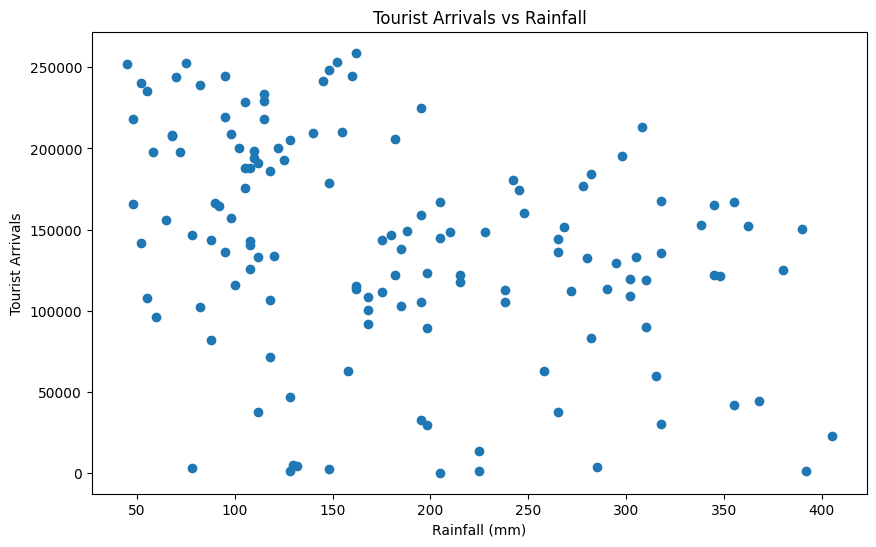

In [493]:
plt.figure(figsize=(10,6))

plt.scatter(
    tourism_weather_df['rainfall'],
    tourism_weather_df['arrivals']
)

plt.title(
    'Tourist Arrivals vs Rainfall'
)

plt.xlabel('Rainfall (mm)')
plt.ylabel('Tourist Arrivals')

plt.show()

# Temperature Scatter Plot

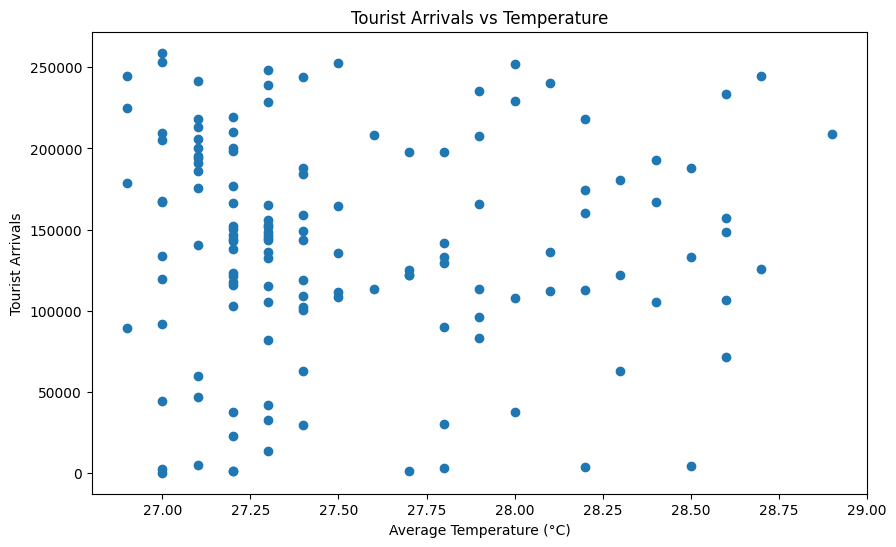

In [494]:
plt.figure(figsize=(10,6))

plt.scatter(
    tourism_weather_df['temperature'],
    tourism_weather_df['arrivals']
)

plt.title(
    'Tourist Arrivals vs Temperature'
)

plt.xlabel('Average Temperature (°C)')
plt.ylabel('Tourist Arrivals')

plt.show()

# Weather Trends

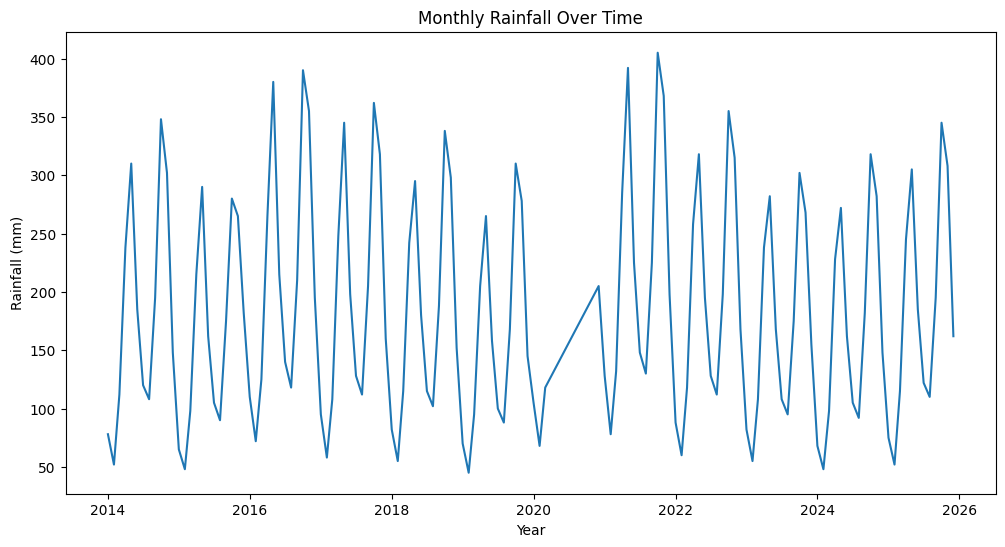

In [495]:
plt.figure(figsize=(12,6))

plt.plot(
    tourism_weather_df['date'],
    tourism_weather_df['rainfall']
)

plt.title('Monthly Rainfall Over Time')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')

plt.show()

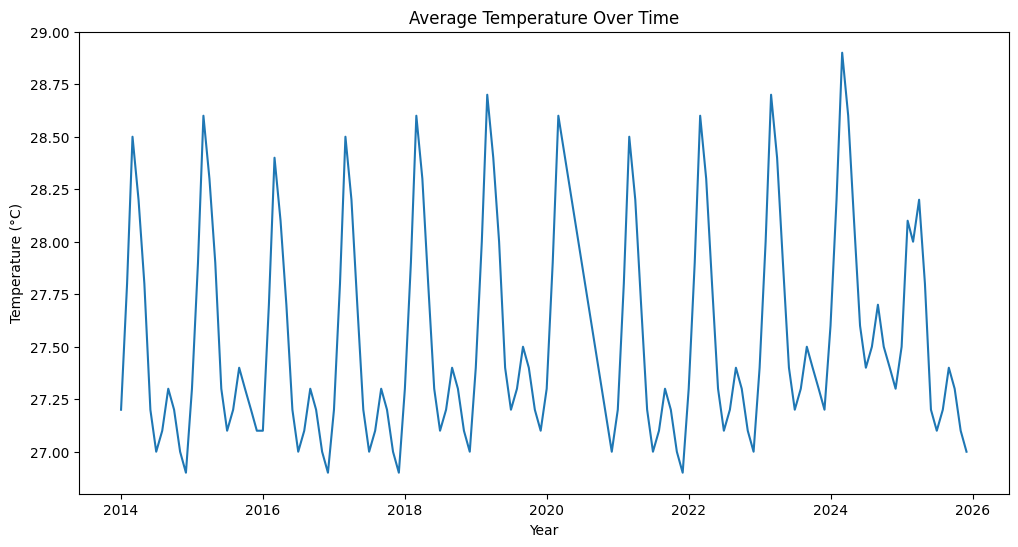

In [496]:
plt.figure(figsize=(12,6))

plt.plot(
    tourism_weather_df['date'],
    tourism_weather_df['temperature']
)

plt.title('Average Temperature Over Time')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')

plt.show()

# Interpretation of Weather Analysis

The correlation analysis revealed a moderate negative relationship between rainfall and tourist arrivals (r = -0.349), indicating that periods of higher rainfall are generally associated with lower tourism demand.

The rainfall trend exhibits strong seasonal variation, which may contribute to the seasonal patterns observed in tourism arrivals. Adverse weather conditions can reduce the attractiveness of outdoor tourism activities and influence travel decisions.

In contrast, average temperature exhibited almost no correlation with tourist arrivals (r = -0.004). This result is expected because Sri Lanka experiences relatively stable tropical temperatures throughout the year, resulting in limited temperature variation.

Overall, rainfall appears to be a useful explanatory variable for tourism demand, while temperature contributes little additional explanatory power.

# Master Tourism Analytics Dataset

All collected datasets are merged into a single master dataset containing tourism arrivals, economic indicators, and weather variables.

This dataset will be used for multivariable analysis, correlation assessment, forecasting, and dashboard development.

In [497]:
# Create master dataset

master_df = df.copy()

# Exchange Rate
master_df = pd.merge(
    master_df,
    exchange_df,
    on='date'
)

# Inflation
master_df = pd.merge(
    master_df,
    inflation_df,
    on='date'
)

# Weather
master_df = pd.merge(
    master_df,
    weather_df,
    on='date'
)

# Peace Index
master_df = pd.merge(
    master_df,
    peace_df,
    on='year'
)

print(master_df.head())
print(master_df.shape)

#Check missing values
print(master_df.isnull().sum())

        date  arrivals     month  year     period  usd_lkr  inflation  \
0 2014-01-01  146575.0   January  2014  Pre-Covid   130.71        4.2   
1 2014-02-01  141878.0  February  2014  Pre-Covid   130.80        3.9   
2 2014-03-01  133048.0     March  2014  Pre-Covid   130.63        4.0   
3 2014-04-01  112631.0     April  2014  Pre-Covid   130.62        3.5   
4 2014-05-01   90046.0       May  2014  Pre-Covid   130.43        3.2   

   rainfall  temperature  peace_index  
0        78         27.2        1.974  
1        52         27.8        1.974  
2       112         28.5        1.974  
3       238         28.2        1.974  
4       310         27.8        1.974  
(136, 10)
date           0
arrivals       0
month          0
year           0
period         0
usd_lkr        0
inflation      0
rainfall       0
temperature    0
peace_index    0
dtype: int64


In [498]:
#Save master datse
master_df.to_csv('../Data/Cleaned/master_tourism_dataset.csv')

In [499]:
print(master_df.columns)

Index(['date', 'arrivals', 'month', 'year', 'period', 'usd_lkr', 'inflation',
       'rainfall', 'temperature', 'peace_index'],
      dtype='str')


# Multivariable Correlation Analysis

A correlation matrix is generated to examine the relationships between tourism arrivals and all explanatory variables simultaneously.

This helps identify the variables most strongly associated with tourism demand.

In [500]:
corr_matrix=master_df[[
    'arrivals',
        'usd_lkr',
        'inflation',
        'rainfall',
        'temperature',
        'peace_index'
]].corr()

print(corr_matrix)

             arrivals   usd_lkr  inflation  rainfall  temperature  peace_index
arrivals     1.000000 -0.156771  -0.408520 -0.349148    -0.003518    -0.056044
usd_lkr     -0.156771  1.000000   0.511438  0.013668     0.076698    -0.598192
inflation   -0.408520  0.511438   1.000000  0.048074    -0.030489    -0.051893
rainfall    -0.349148  0.013668   0.048074  1.000000    -0.125698     0.085361
temperature -0.003518  0.076698  -0.030489 -0.125698     1.000000    -0.117714
peace_index -0.056044 -0.598192  -0.051893  0.085361    -0.117714     1.000000


# Heatmap

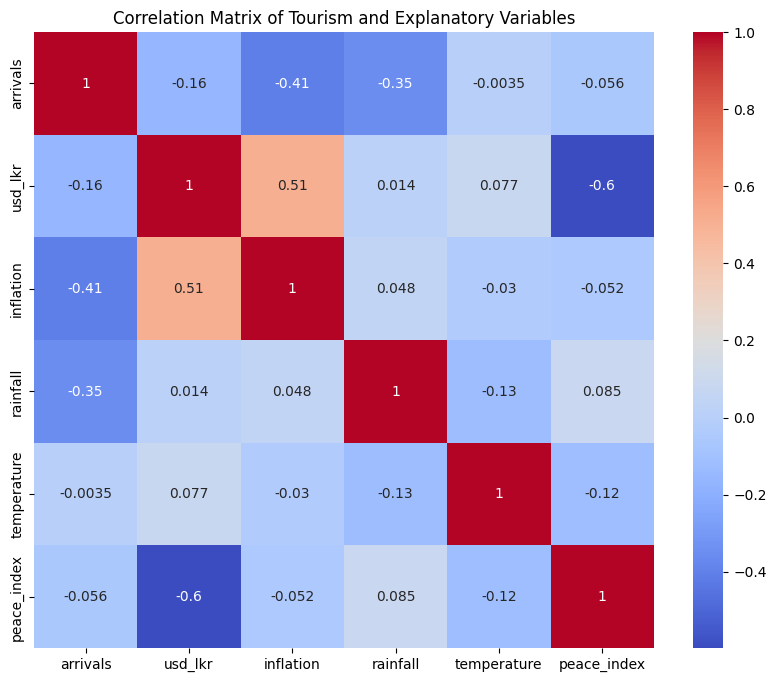

In [501]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Tourism and Explanatory Variables')

plt.show()

# Forecast Model with External Factors

A multivariable forecasting model is developed using Prophet with external regressors.

Inflation and rainfall are included as explanatory variables because they exhibited the strongest relationships with tourism arrivals during the correlation analysis.

In [503]:
forecast_reg_df=master_df[[
    'date',
        'arrivals',
        'inflation',
        'rainfall'
]].copy()

forecast_reg_df.rename(columns={
    'date':'ds',
    'arrivals':'y'
},inplace=True)

print(forecast_reg_df.head())

          ds         y  inflation  rainfall
0 2014-01-01  146575.0        4.2        78
1 2014-02-01  141878.0        3.9        52
2 2014-03-01  133048.0        4.0       112
3 2014-04-01  112631.0        3.5       238
4 2014-05-01   90046.0        3.2       310


In [504]:
#Train/Test Split
train_reg=forecast_reg_df[forecast_reg_df['ds']<'2024-01-01']
test_reg=forecast_reg_df[forecast_reg_df['ds']>='2024-01-01']

print("Training:", train_reg.shape)
print("Testing:", test_reg.shape)

Training: (112, 4)
Testing: (24, 4)


In [505]:
model3=Prophet()
model3.add_regressor('inflation')
model3.add_regressor('rainfall')

# Train Model 3

In [506]:
model3.fit(train_reg)

11:04:16 - cmdstanpy - INFO - Chain [1] start processing
11:04:16 - cmdstanpy - INFO - Chain [1] done processing


# Create Forecast for Test Period

In [508]:
forecast3=model3.predict(test_reg)
forecast3[['ds','yhat','yhat_lower','yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,139871.864069,80259.984413,196248.756433
1,2024-02-01,132004.699357,73131.837826,188557.016160
2,2024-03-01,117476.904735,60150.604054,176318.091145
3,2024-04-01,88568.622019,33279.010297,149256.696249
4,2024-05-01,81855.570491,26304.052080,140439.279266


# Evaluate Model 3

In [509]:
actual3 = test_reg['y'].values

predicted3 = forecast3['yhat'].values

mae3 = mean_absolute_error(
    actual3,
    predicted3
)

rmse3 = np.sqrt(
    mean_squared_error(
        actual3,
        predicted3
    )
)

print("Model 3 MAE:", round(mae3,2))
print("Model 3 RMSE:", round(rmse3,2))

Model 3 MAE: 91928.77
Model 3 RMSE: 96980.75


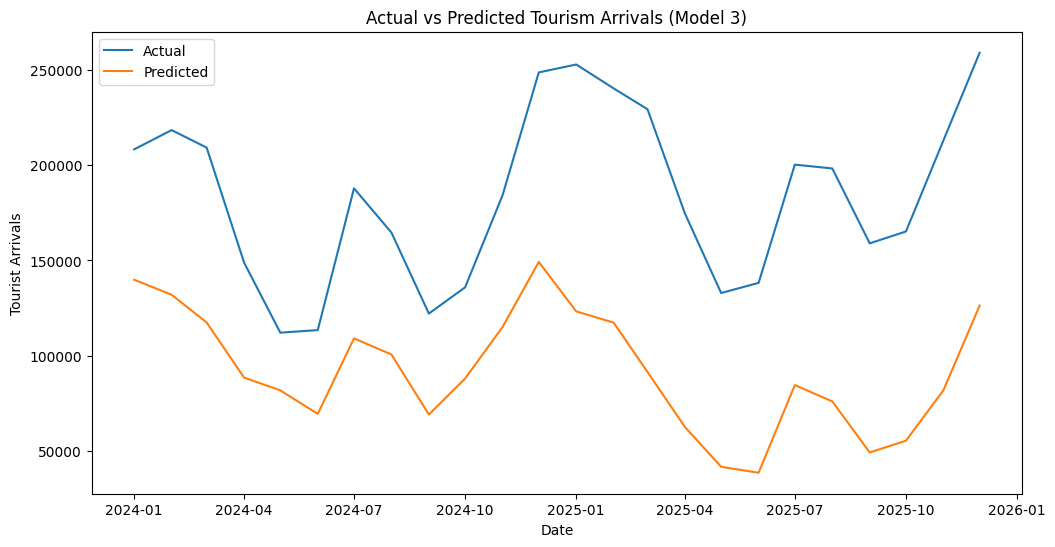

In [510]:
plt.figure(figsize=(12,6))

plt.plot(
    test_reg['ds'],
    actual3,
    label='Actual'
)

plt.plot(
    test_reg['ds'],
    predicted3,
    label='Predicted'
)

plt.title(
    'Actual vs Predicted Tourism Arrivals (Model 3)'
)

plt.xlabel('Date')
plt.ylabel('Tourist Arrivals')

plt.legend()

plt.show()

# Evaluation of Prophet Model with External Factors

The forecasting performance of the multivariable Prophet model is evaluated using MAE and RMSE metrics.

The model incorporates inflation and rainfall as external regressors to assess whether explanatory variables improve forecasting accuracy compared with the baseline time-series models.

# Model 4: Prophet + Inflation + Rainfall (Without COVID Period)

In [511]:
# Remove COVID years (2020 and 2021)

train_reg_no_covid = train_reg[
    ~train_reg['ds'].dt.year.isin([2020, 2021])
]

print("Original Training Records:", len(train_reg))
print("Training Records Without COVID:", len(train_reg_no_covid))

Original Training Records: 112
Training Records Without COVID: 96


In [512]:
from prophet import Prophet

# Create Prophet model

model4 = Prophet()

# Add external regressors

model4.add_regressor('inflation')
model4.add_regressor('rainfall')

In [513]:
# Train model

model4.fit(train_reg_no_covid)

11:22:15 - cmdstanpy - INFO - Chain [1] start processing
11:22:15 - cmdstanpy - INFO - Chain [1] done processing


In [514]:
forecast4 = model4.predict(test_reg)

forecast4[
    ['ds','yhat','yhat_lower','yhat_upper']
].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,165053.356010,135638.677774,196186.401427
1,2024-02-01,177839.722070,148265.435130,209127.095759
2,2024-03-01,176898.212993,144457.792454,207132.414359
3,2024-04-01,122274.862500,89835.111274,151896.329509
4,2024-05-01,78035.049123,48232.567981,109583.716081


In [515]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Actual values

actual4 = test_reg['y'].values

# Predicted values

predicted4 = forecast4['yhat'].values

# MAE

mae4 = mean_absolute_error(
    actual4,
    predicted4
)

# RMSE

rmse4 = np.sqrt(
    mean_squared_error(
        actual4,
        predicted4
    )
)

print("Model 4 MAE:", round(mae4,2))
print("Model 4 RMSE:", round(rmse4,2))

Model 4 MAE: 46449.87
Model 4 RMSE: 49962.73


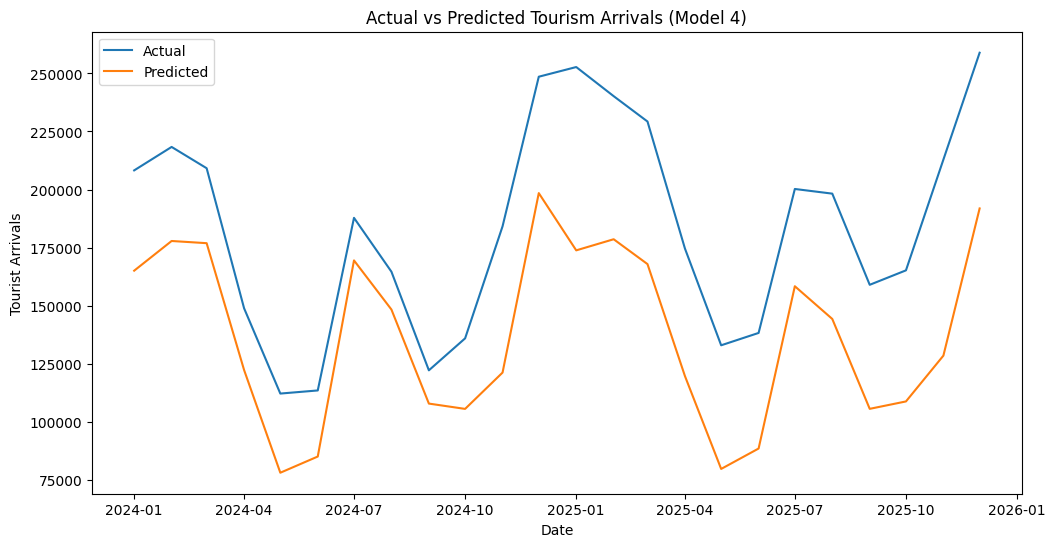

In [516]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    test_reg['ds'],
    actual4,
    label='Actual'
)

plt.plot(
    test_reg['ds'],
    predicted4,
    label='Predicted'
)

plt.title(
    'Actual vs Predicted Tourism Arrivals (Model 4)'
)

plt.xlabel('Date')
plt.ylabel('Tourist Arrivals')

plt.legend()

plt.show()

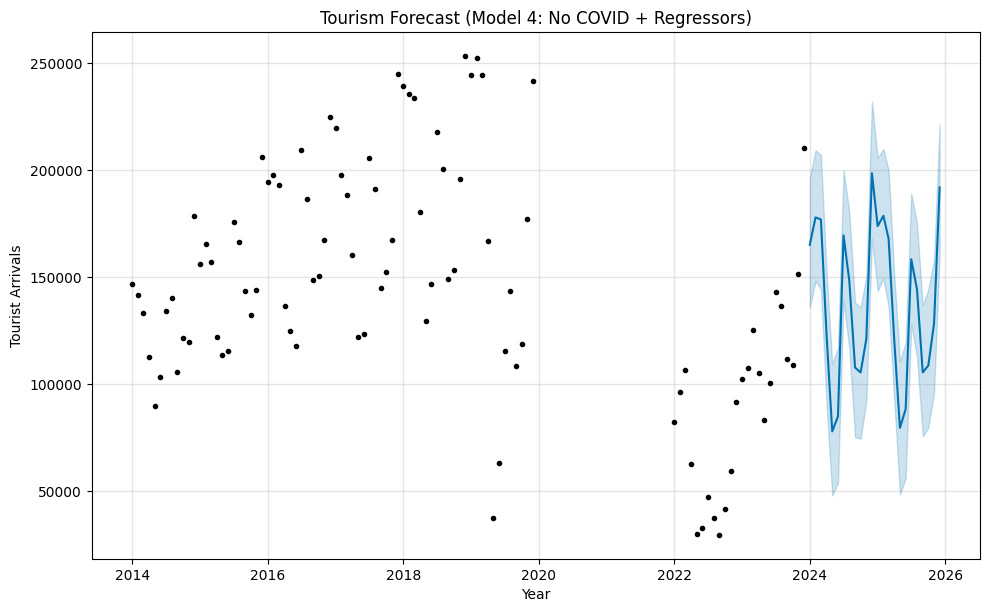

In [517]:
fig = model4.plot(forecast4)

plt.title(
    'Tourism Forecast (Model 4: No COVID + Regressors)'
)

plt.xlabel('Year')
plt.ylabel('Tourist Arrivals')

plt.show()

In [518]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1 - Prophet',
        'Model 2 - No COVID',
        'Model 3 - Regressors',
        'Model 4 - No COVID + Regressors'
    ],
    'MAE': [
        120215,
        108252,
        91929,
        mae4
    ],
    'RMSE': [
        122659,
        110545,
        96981,
        rmse4
    ]
})

print(comparison)

                             Model            MAE           RMSE
0                Model 1 - Prophet  120215.000000  122659.000000
1               Model 2 - No COVID  108252.000000  110545.000000
2             Model 3 - Regressors   91929.000000   96981.000000
3  Model 4 - No COVID + Regressors   46449.871728   49962.728942


# Global Travel Demand Index Analysis

In [519]:
global_df = pd.read_csv(
    "../Data/Raw/global_travel_demand_monthly_2014_2026.csv"
)

print(global_df.head())

   Year     Month  International_Arrivals_Millions  YoY_Change_Pct  \
0  2014   January                             87.5             4.8   
1  2014  February                             80.2             5.1   
2  2014     March                             92.4             4.9   
3  2014     April                            105.6             5.2   
4  2014       May                            112.8             5.0   

   Tourism_Receipts_USD_Billion  Global_Travel_Demand_Index_2019=100  \
0                          97.2                                 59.2   
1                          89.1                                 54.3   
2                         102.7                                 62.5   
3                         117.3                                 71.4   
4                         125.4                                 76.3   

                                Key_Events_Notes  
0                Strong growth; Americas led +8%  
1  Steady growth; geopolitical tensions (Cri

In [520]:
#Create date column
global_df['date'] = pd.to_datetime(
    global_df['Year'].astype(str)
    + '-'
    + global_df['Month']
)

global_df.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20012\839022626.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  global_df['date'] = pd.to_datetime(


,Year,Month,International_Arrivals_Millions,YoY_Change_Pct,Tourism_Receipts_USD_Billion,Global_Travel_Demand_Index_2019=100,Key_Events_Notes,date
0,2014,January,87.5,4.8,97.2,59.2,Strong growth; Americas led +8%,2014-01-01
1,2014,February,80.2,5.1,89.1,54.3,Steady growth; geopolitical tensions (Crimea),2014-02-01
2,2014,March,92.4,4.9,102.7,62.5,Inter-season pick-up,2014-03-01
3,2014,April,105.6,5.2,117.3,71.4,Spring travel surge,2014-04-01
4,2014,May,112.8,5.0,125.4,76.3,Pre-summer rise,2014-05-01


In [521]:
#Keep only requaired columns
global_df = global_df[
    ['date',
     'Global_Travel_Demand_Index_2019=100']
]

global_df.rename(
    columns={
        'Global_Travel_Demand_Index_2019=100':
        'global_demand'
    },
    inplace=True
)

print(global_df.head())

        date  global_demand
0 2014-01-01           59.2
1 2014-02-01           54.3
2 2014-03-01           62.5
3 2014-04-01           71.4
4 2014-05-01           76.3


In [522]:
#Merge with tourism data
tourism_global_df = pd.merge(
    df,
    global_df,
    on='date'
)

print(tourism_global_df.head())

        date  arrivals     month  year     period  global_demand
0 2014-01-01  146575.0   January  2014  Pre-Covid           59.2
1 2014-02-01  141878.0  February  2014  Pre-Covid           54.3
2 2014-03-01  133048.0     March  2014  Pre-Covid           62.5
3 2014-04-01  112631.0     April  2014  Pre-Covid           71.4
4 2014-05-01   90046.0       May  2014  Pre-Covid           76.3


# Correlation Analysis

In [523]:
corr = tourism_global_df[
    ['arrivals','global_demand']
].corr()

print(corr)

               arrivals  global_demand
arrivals       1.000000       0.389687
global_demand  0.389687       1.000000


# Scatter Plot

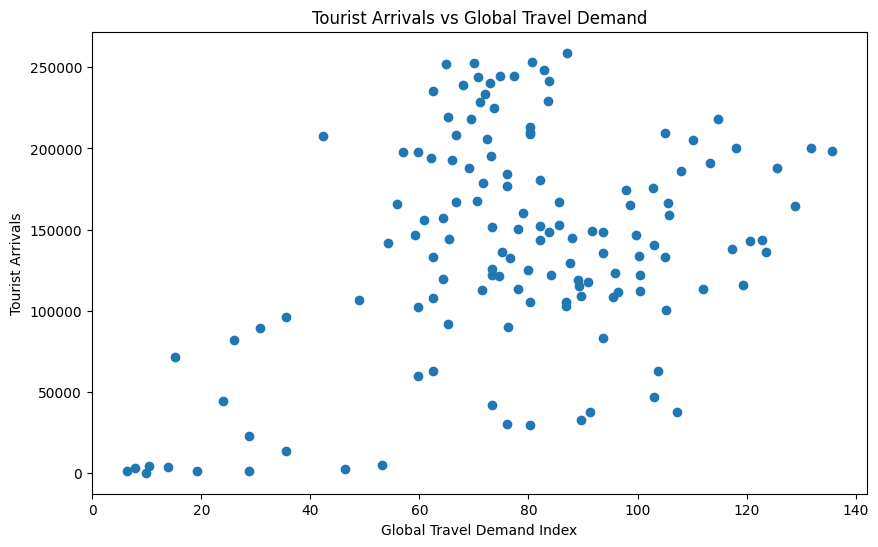

In [524]:
plt.figure(figsize=(10,6))

plt.scatter(
    tourism_global_df['global_demand'],
    tourism_global_df['arrivals']
)

plt.title(
    'Tourist Arrivals vs Global Travel Demand'
)

plt.xlabel('Global Travel Demand Index')

plt.ylabel('Tourist Arrivals')

plt.show()

# Model 5: Prophet + Inflation + Rainfall + Global Travel Demand Index (Without COVID Period)

In [525]:
print(global_df.head())

        date  global_demand
0 2014-01-01           59.2
1 2014-02-01           54.3
2 2014-03-01           62.5
3 2014-04-01           71.4
4 2014-05-01           76.3


# Final Forecast Model with Multiple Explanatory Variables

A final forecasting model is developed using inflation, rainfall, and global travel demand as external regressors.

These variables were selected based on correlation analysis and theoretical relevance to tourism demand.

The COVID-19 disruption period is excluded from training to improve trend estimation.

In [526]:
forecast_final_df = pd.merge(
    master_df,
    global_df,
    on='date'
)

forecast_final_df = forecast_final_df[
    [
        'date',
        'arrivals',
        'inflation',
        'rainfall',
        'global_demand'
    ]
]

forecast_final_df.rename(
    columns={
        'date':'ds',
        'arrivals':'y'
    },
    inplace=True
)

print(forecast_final_df.head())

          ds         y  inflation  rainfall  global_demand
0 2014-01-01  146575.0        4.2        78           59.2
1 2014-02-01  141878.0        3.9        52           54.3
2 2014-03-01  133048.0        4.0       112           62.5
3 2014-04-01  112631.0        3.5       238           71.4
4 2014-05-01   90046.0        3.2       310           76.3


In [527]:
# Create Train/Test Split
train_final = forecast_final_df[
    forecast_final_df['ds'] < '2024-01-01'
]

test_final = forecast_final_df[
    forecast_final_df['ds'] >= '2024-01-01'
]

print("Training Records:", len(train_final))
print("Testing Records:", len(test_final))

Training Records: 112
Testing Records: 24


In [529]:
#Remove COVID From Training Data
train_final_no_covid = train_final[
    ~train_final['ds'].dt.year.isin([2020, 2021])
]

print(
    "Training Records Without COVID:",
    len(train_final_no_covid)
)

Training Records Without COVID: 96


In [530]:
from prophet import Prophet

model5 = Prophet()

model5.add_regressor('inflation')
model5.add_regressor('rainfall')
model5.add_regressor('global_demand')

In [531]:
model5.fit(train_final_no_covid)

11:57:29 - cmdstanpy - INFO - Chain [1] start processing
11:57:30 - cmdstanpy - INFO - Chain [1] done processing


In [532]:
forecast5 = model5.predict(
    test_final
)

forecast5[
    ['ds','yhat','yhat_lower','yhat_upper']
].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,157723.306411,133251.924295,185064.893732
1,2024-02-01,189465.175123,161998.970715,215001.837600
2,2024-03-01,191871.836419,165148.637581,216100.406201
3,2024-04-01,144367.901774,117594.913278,170012.349987
4,2024-05-01,84058.259153,57598.030619,109769.071445


# Calculate MAE and RMSE

In [533]:
actual5 = test_final['y'].values
predicted5 = forecast5['yhat'].values

mae5 = mean_absolute_error(
    actual5,
    predicted5
)

rmse5 = np.sqrt(
    mean_squared_error(
        actual5,
        predicted5
    )
)

print("Model 5 MAE:", round(mae5,2))
print("Model 5 RMSE:", round(rmse5,2))

Model 5 MAE: 26220.59
Model 5 RMSE: 32819.25


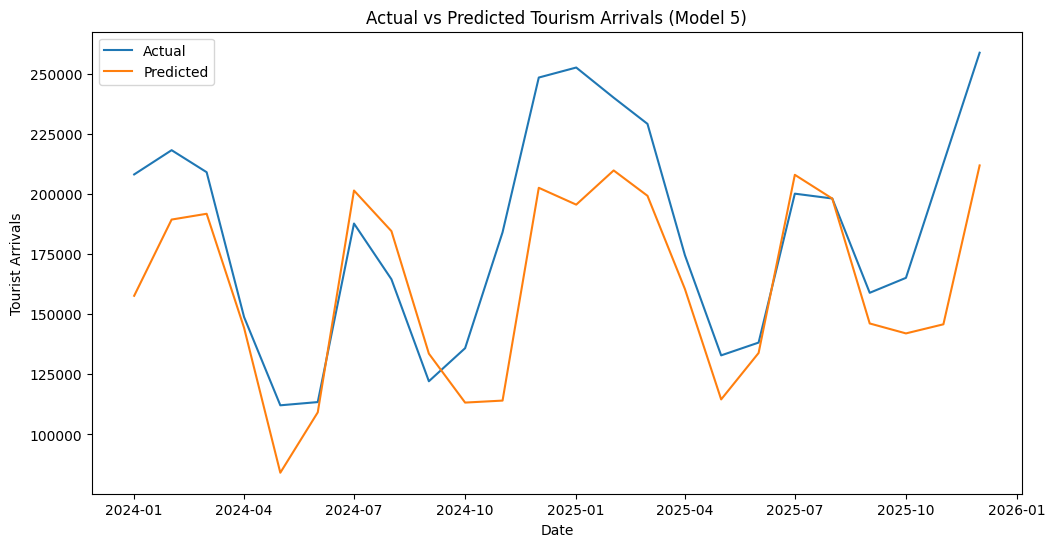

In [534]:
plt.figure(figsize=(12,6))

plt.plot(
    test_final['ds'],
    actual5,
    label='Actual'
)

plt.plot(
    test_final['ds'],
    predicted5,
    label='Predicted'
)

plt.title(
    'Actual vs Predicted Tourism Arrivals (Model 5)'
)

plt.xlabel('Date')
plt.ylabel('Tourist Arrivals')

plt.legend()

plt.show()

# Final Model Comparison

In [535]:
comparison = pd.DataFrame({
    'Model':[
        'Model 1',
        'Model 2',
        'Model 3',
        'Model 4',
        'Model 5'
    ],
    'MAE':[
        120215,
        108252,
        91929,
        46450,
        mae5
    ],
    'RMSE':[
        122659,
        110545,
        96981,
        49963,
        rmse5
    ]
})

print(comparison)

     Model            MAE           RMSE
0  Model 1  120215.000000  122659.000000
1  Model 2  108252.000000  110545.000000
2  Model 3   91929.000000   96981.000000
3  Model 4   46450.000000   49963.000000
4  Model 5   26220.592916   32819.248586
